# 03 — EDA

Análisis exploratorio del corpus de minutas FOMC etiquetado. El objetivo es caracterizar el dataset antes de modelar y justificar las decisiones metodológicas (split cronológico, F1-macro como métrica, importancia de los embeddings contextuales).

**Input:** `data/processed/fomc_dataset.csv`

**Outputs:** figuras en `reports/figures/`

In [1]:
import pandas as pd
import numpy as np
import string
from pathlib import Path
from collections import Counter

import matplotlib.pyplot as plt
import seaborn as sns
import requests

from sklearn.feature_extraction.text import TfidfVectorizer
from IPython.display import display

sns.set_theme(style='whitegrid', palette='Set2')
pd.options.display.max_colwidth = 300

# Rutas
BASE_DIR     = Path('..').resolve()
DATA_RAW     = BASE_DIR / 'data' / 'raw'
LEXICONS_DIR = DATA_RAW / 'lexicons'
DATA_PROCESSED = BASE_DIR / 'data' / 'processed'
REPORTS_DIR  = BASE_DIR / 'reports' / 'figures'

LEXICONS_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

def save_fig(name):
    plt.savefig(REPORTS_DIR / name, dpi=120, bbox_inches='tight')

# Cargar dataset
df = pd.read_csv(DATA_PROCESSED / 'fomc_dataset.csv', parse_dates=['date'])
df['year']  = df['date'].dt.year
df['epoch'] = df['year'].apply(lambda y: 'pre-2005' if y < 2005 else 'post-2005')

LABEL_ORDER = ['hike', 'cut', 'hold']
SPLIT_ORDER = ['train', 'val', 'test']

print(f'Dataset: {df.shape}')
print(df['label'].value_counts())
print(df['split'].value_counts())

Dataset: (193, 6)
label
hold    131
hike     39
cut      23
Name: count, dtype: int64
split
train    153
test      24
val       16
Name: count, dtype: int64


## 1. Distribución de clases

La clase `hold` domina el dataset, reflejando los largos períodos de estabilidad monetaria (2009–2015 y 2020–2021). Esto implica que un clasificador trivial (predice siempre `hold`) ya obtiene una accuracy razonable — la métrica relevante para este problema es **F1-macro**, que penaliza el desbalance de clases. También reportamos la accuracy del clasificador trivial como cota inferior para los experimentos.

split,test,train,val,All
label,,,,
cut,0,18,5,23
hike,11,27,1,39
hold,13,108,10,131
All,24,153,16,193


Clase mayoritaria (train): hold
Accuracy trivial (majority class): 67.88%
-> F1-macro es la metrica principal para superar este baseline.


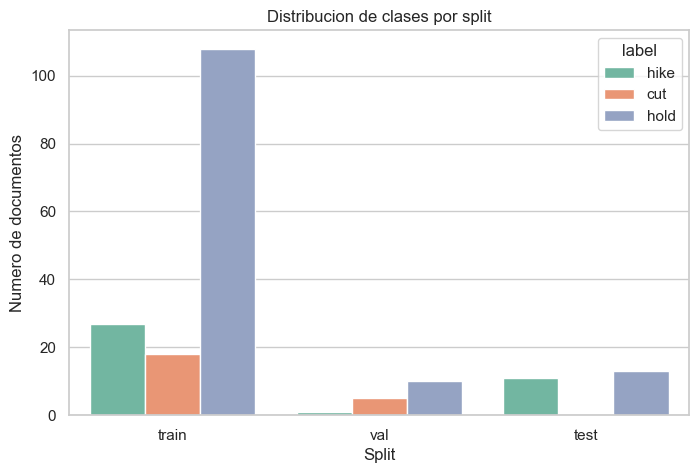

In [2]:
# Tabla de distribución por clase y split
tabla = pd.crosstab(df['label'], df['split'], margins=True)
display(tabla)

# Baseline trivial: clase mayoritaria
most_freq    = df.loc[df['split'] == 'train', 'label'].mode()[0]
acc_trivial  = (df['label'] == most_freq).mean()
print(f'Clase mayoritaria (train): {most_freq}')
print(f'Accuracy trivial (majority class): {acc_trivial:.2%}')
print('-> F1-macro es la metrica principal para superar este baseline.')

# Barplot
fig, ax = plt.subplots(figsize=(8, 5))
plot_df = df.groupby(['split', 'label']).size().reset_index(name='count')
sns.barplot(data=plot_df, x='split', y='count', hue='label',
            order=SPLIT_ORDER, hue_order=LABEL_ORDER, ax=ax)
ax.set_title('Distribucion de clases por split')
ax.set_xlabel('Split')
ax.set_ylabel('Numero de documentos')
save_fig('03_class_distribution.png')
plt.show()

## 2. Longitud de documentos

A partir de 2005 el FOMC comenzó a publicar transcripciones con mayor detalle de debate, lo que produjo minutas significativamente más largas. Esto tiene dos consecuencias para el modelado:
- **TF-IDF**: vocabulario más rico post-2005, posible sesgo léxico entre regímenes.
- **FinBERT**: límite de 512 tokens → truncación significativa en documentos largos. Documentamos qué fracción del corpus supera ese umbral.

Palabras por documento — por clase:


,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
cut,23,4012,1428,2485,2806,3564,5041,7453
hike,39,3844,1532,1946,2392,4111,4946,8119
hold,131,4452,1391,1934,3923,4473,5205,8173



Palabras por documento — por epoca:


,count,mean,std,min,25%,50%,75%,max
epoch,,,,,,,,
post-2005,153,4682,1298,1946,4094,4691,5360,8173
pre-2005,40,2725,732,1934,2304,2491,2790,4988



% docs > 512 palabras (proxy truncado FinBERT):
  Total corpus : 100%
  post-2005    : 100%


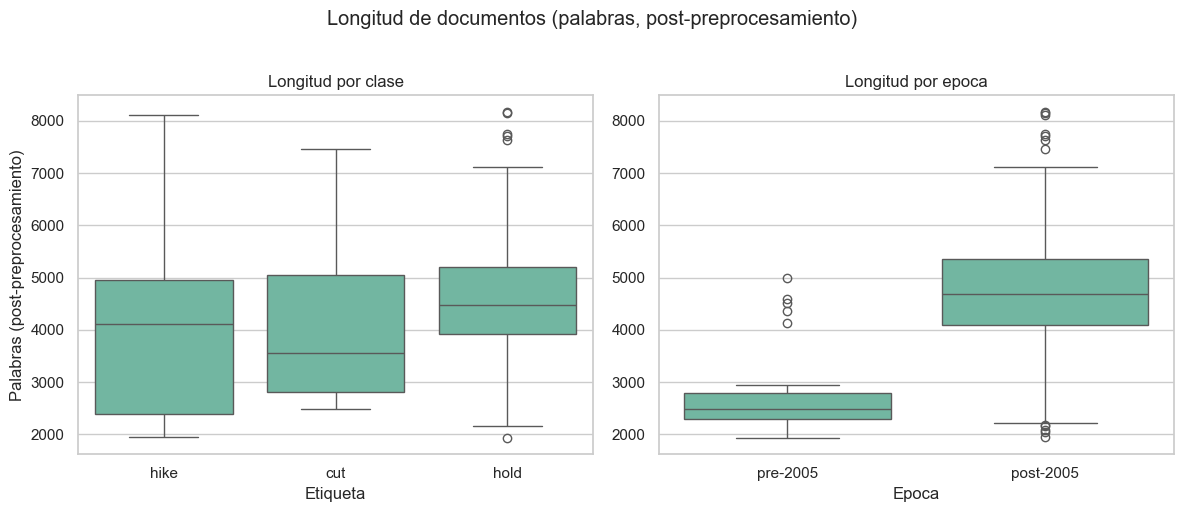

In [3]:
df['n_words'] = df['text'].str.split().str.len()

# Estadísticas descriptivas
print('Palabras por documento — por clase:')
display(df.groupby('label')['n_words'].describe().round(0).astype(int))
print()
print('Palabras por documento — por epoca:')
display(df.groupby('epoch')['n_words'].describe().round(0).astype(int))

# Fraccion de docs > 512 palabras (proxy truncado FinBERT)
pct_all  = (df['n_words'] > 512).mean()
pct_post = (df.loc[df['epoch'] == 'post-2005', 'n_words'] > 512).mean()
print(f'\n% docs > 512 palabras (proxy truncado FinBERT):')
print(f'  Total corpus : {pct_all:.0%}')
print(f'  post-2005    : {pct_post:.0%}')

# Boxplots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(data=df, x='label', y='n_words', order=LABEL_ORDER, ax=axes[0])
axes[0].set_title('Longitud por clase')
axes[0].set_xlabel('Etiqueta')
axes[0].set_ylabel('Palabras (post-preprocesamiento)')

sns.boxplot(data=df, x='epoch', y='n_words', order=['pre-2005', 'post-2005'], ax=axes[1])
axes[1].set_title('Longitud por epoca')
axes[1].set_xlabel('Epoca')
axes[1].set_ylabel('')

plt.suptitle('Longitud de documentos (palabras, post-preprocesamiento)', y=1.02)
plt.tight_layout()
save_fig('03_doc_length_boxplot.png')
plt.show()

## 3. Vocabulario por clase

Analizamos el vocabulario discriminativo de dos formas:
1. **Frecuencia bruta**: palabras más comunes por clase (stopwords y términos de dominio ya removidos).
2. **TF-IDF discriminativo**: score TF-IDF promedio por clase sobre el conjunto train — penaliza palabras que aparecen en todas las clases y resalta las específicas de cada una.

Si `hike` y `cut` muestran vocabulario claramente diferenciado de `hold`, TF-IDF + LR (experimento 1) debería capturar señal léxica. Si el overlap es alto, los métodos de embeddings contextuales serán necesarios.

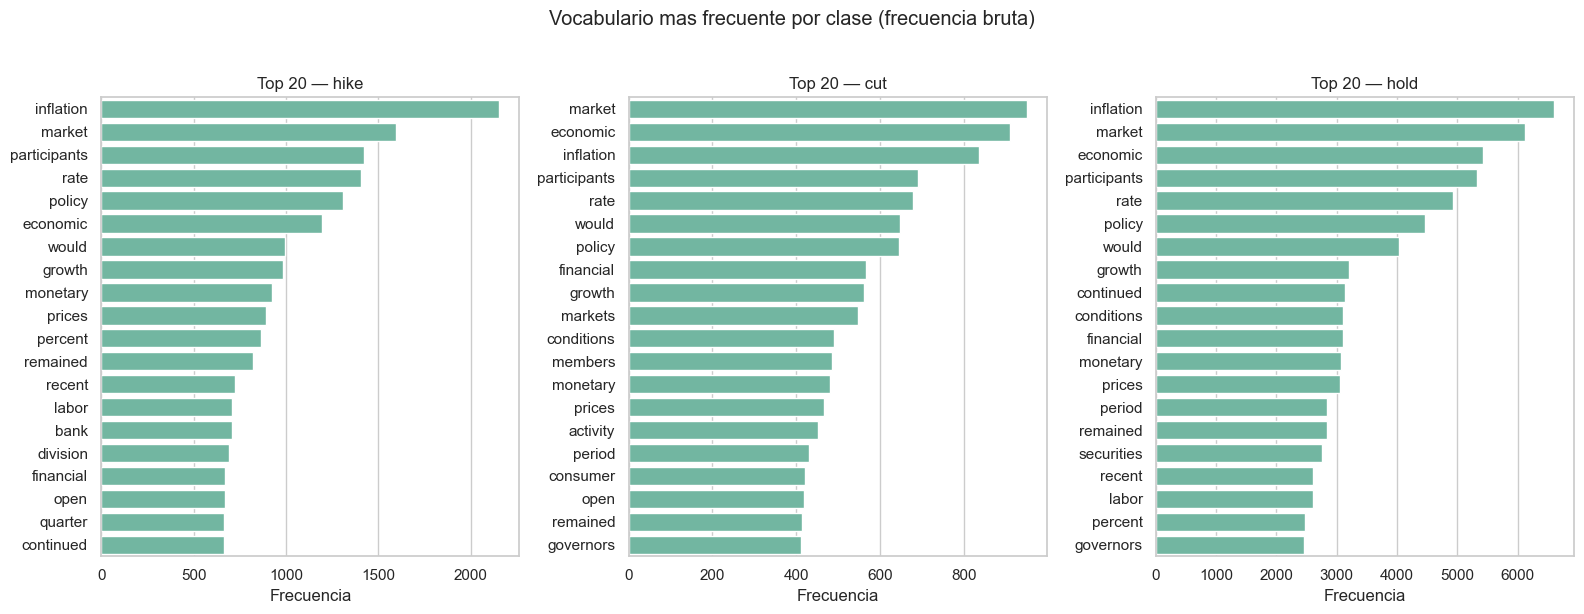

In [4]:
TOP_N = 20

fig, axes = plt.subplots(1, 3, figsize=(16, 6))
for ax, label in zip(axes, LABEL_ORDER):
    tokens = []
    for doc in df.loc[df['label'] == label, 'text']:
        tokens.extend(str(doc).split())
    top = Counter(tokens).most_common(TOP_N)
    words, freqs = zip(*top)
    sns.barplot(x=list(freqs), y=list(words), ax=ax, orient='h')
    ax.set_title(f'Top {TOP_N} — {label}')
    ax.set_xlabel('Frecuencia')
    ax.set_ylabel('')

plt.suptitle('Vocabulario mas frecuente por clase (frecuencia bruta)', y=1.02)
plt.tight_layout()
save_fig('03_top20_vocab_per_class.png')
plt.show()

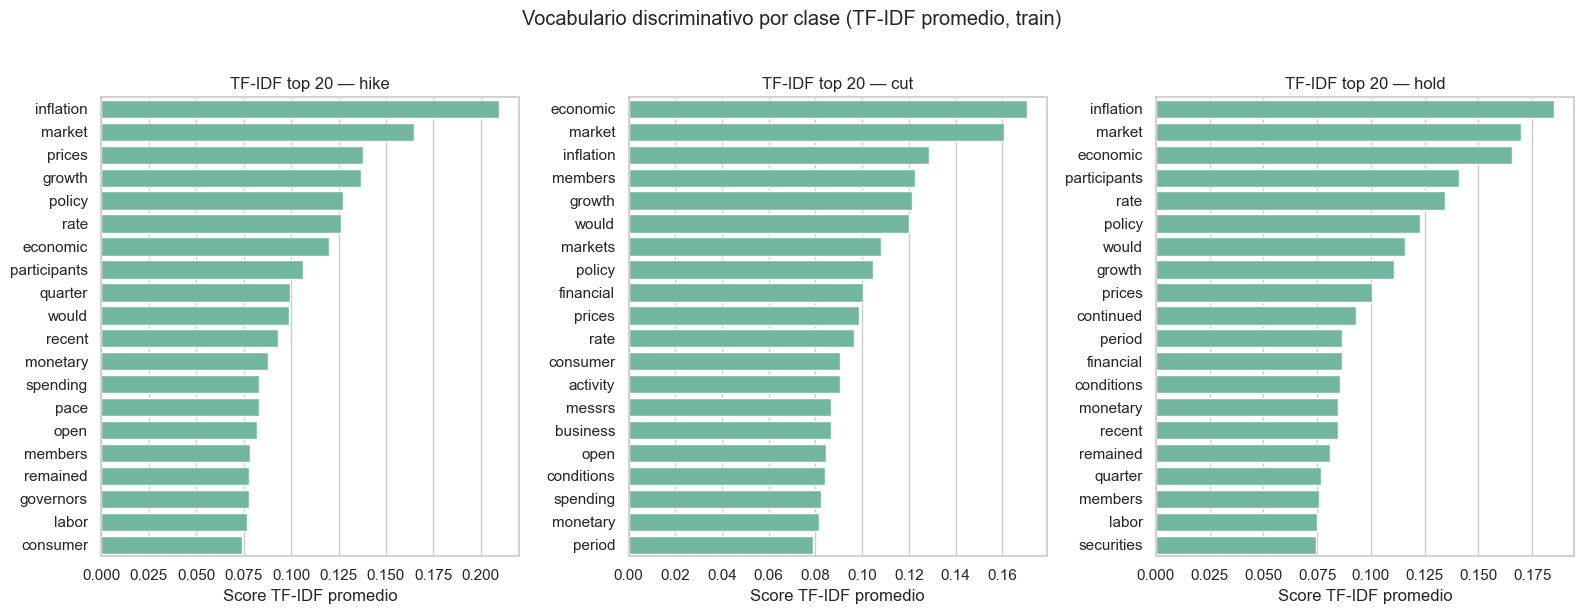

In [5]:
# TF-IDF discriminativo sobre train
train_mask   = df['split'] == 'train'
train_labels = df.loc[train_mask, 'label'].values

tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 1))
X_train = tfidf.fit_transform(df.loc[train_mask, 'text'])
feature_names = tfidf.get_feature_names_out()

fig, axes = plt.subplots(1, 3, figsize=(16, 6))
for ax, label in zip(axes, LABEL_ORDER):
    mask_label  = train_labels == label
    mean_scores = np.asarray(X_train[mask_label].mean(axis=0)).ravel()
    top_idx     = mean_scores.argsort()[-TOP_N:][::-1]
    top_words   = feature_names[top_idx]
    top_scores  = mean_scores[top_idx]
    sns.barplot(x=top_scores, y=top_words, ax=ax, orient='h')
    ax.set_title(f'TF-IDF top {TOP_N} — {label}')
    ax.set_xlabel('Score TF-IDF promedio')
    ax.set_ylabel('')

plt.suptitle('Vocabulario discriminativo por clase (TF-IDF promedio, train)', y=1.02)
plt.tight_layout()
save_fig('03_tfidf_top20_per_class.png')
plt.show()

## 4. Drift temporal

Analizamos el drift en dos dimensiones:
1. **Drift de etiquetas**: distribución de `hike`/`cut`/`hold` por año — permite ver los regímenes monetarios históricos.
2. **Drift de vocabulario**: comparamos el top-200 de palabras pre-2005 vs post-2005 con similitud de Jaccard. Un Jaccard bajo justifica el split cronológico fijo: un split aleatorio mezclaría regímenes y vocabulario, inflando las métricas de evaluación.

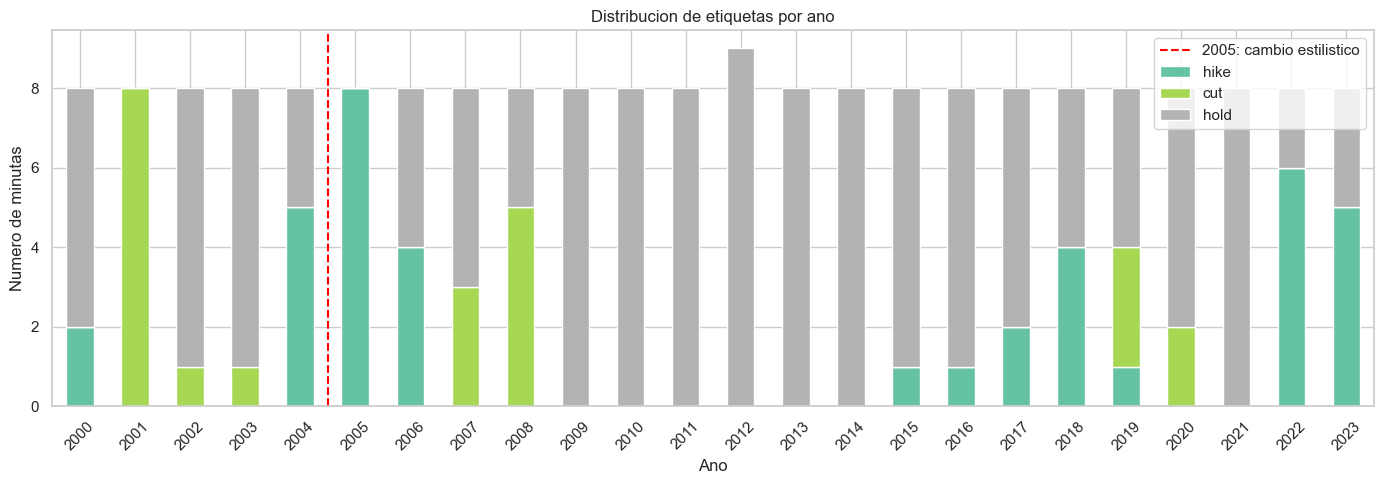

In [6]:
# Drift de etiquetas por año
pivot_labels = pd.crosstab(df['year'], df['label'])

fig, ax = plt.subplots(figsize=(14, 5))
cols_order = [c for c in LABEL_ORDER if c in pivot_labels.columns]
pivot_labels[cols_order].plot.bar(stacked=True, ax=ax, colormap='Set2')

years_list = list(pivot_labels.index)
if 2005 in years_list:
    pos_2005 = years_list.index(2005) - 0.5
    ax.axvline(x=pos_2005, color='red', linestyle='--', linewidth=1.5, label='2005: cambio estilistico')
    ax.legend()

ax.set_title('Distribucion de etiquetas por ano')
ax.set_xlabel('Ano')
ax.set_ylabel('Numero de minutas')
plt.xticks(rotation=45)
plt.tight_layout()
save_fig('03_temporal_drift_labels.png')
plt.show()

Jaccard similarity (top-200, pre vs post-2005): 0.538
  Solo pre-2005 : 60 palabras
  Compartidas   : 140 palabras
  Solo post-2005: 60 palabras
Muestra exclusivas pre-2005 : ['action', 'aggregate', 'ahead', 'anecdotal', 'august', 'available', 'basis', 'capital', 'chairman', 'confidence']
Muestra exclusivas post-2005: ['accommodative', 'addition', 'agency', 'although', 'appropriate', 'april', 'asset', 'associate', 'billion', 'changed']


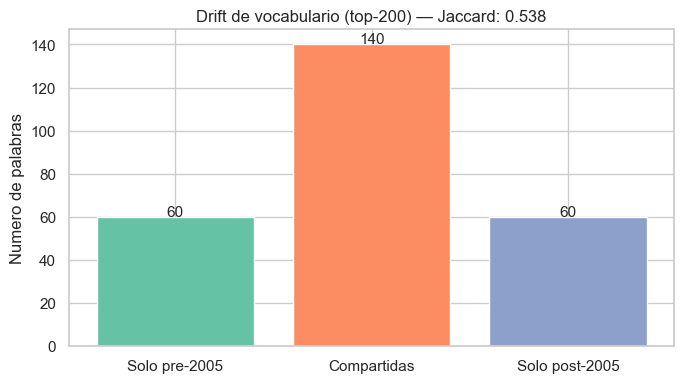

In [7]:
# Drift de vocabulario: top-200 pre vs post-2005
def top_vocab(docs, n=200):
    tokens = []
    for doc in docs:
        tokens.extend(str(doc).split())
    return set([w for w, _ in Counter(tokens).most_common(n)])

vocab_pre  = top_vocab(df.loc[df['epoch'] == 'pre-2005',  'text'])
vocab_post = top_vocab(df.loc[df['epoch'] == 'post-2005', 'text'])

only_pre  = vocab_pre  - vocab_post
only_post = vocab_post - vocab_pre
shared    = vocab_pre  & vocab_post
jaccard   = len(shared) / len(vocab_pre | vocab_post)

print(f'Jaccard similarity (top-200, pre vs post-2005): {jaccard:.3f}')
print(f'  Solo pre-2005 : {len(only_pre)} palabras')
print(f'  Compartidas   : {len(shared)} palabras')
print(f'  Solo post-2005: {len(only_post)} palabras')
print(f'Muestra exclusivas pre-2005 : {sorted(list(only_pre))[:10]}')
print(f'Muestra exclusivas post-2005: {sorted(list(only_post))[:10]}')

fig, ax = plt.subplots(figsize=(7, 4))
sizes      = [len(only_pre), len(shared), len(only_post)]
labels_bar = ['Solo pre-2005', 'Compartidas', 'Solo post-2005']
colors     = ['#66c2a5', '#fc8d62', '#8da0cb']
ax.bar(labels_bar, sizes, color=colors)
ax.set_title(f'Drift de vocabulario (top-200) — Jaccard: {jaccard:.3f}')
ax.set_ylabel('Numero de palabras')
for i, v in enumerate(sizes):
    ax.text(i, v + 0.5, str(v), ha='center', fontsize=11)
plt.tight_layout()
save_fig('03_temporal_drift_vocab.png')
plt.show()

## 5. Análisis Loughran-McDonald

El lexicón Loughran-McDonald (LM) es el estándar para análisis de sentimiento en textos financieros. Cubre seis categorías de tono:
- **Positive / Negative**: polaridad de sentimiento
- **Uncertainty**: lenguaje hedging y vaguedad
- **Litigious**: términos legales y de responsabilidad
- **Constraining**: restricciones y obligaciones
- **Superfluous**: palabras de relleno

Calculamos el score de cada categoría como la fracción de tokens del documento que pertenecen al conjunto. Analizamos los scores promedio por clase y por época.

Hipótesis intuitivas: `Negative` debería ser más alto en minutas `cut`; `Uncertainty` más alto en transiciones de régimen. Si se confirman, esto motiva el experimento 2 (LM lexicón + LR).

In [8]:
LM_PATH = LEXICONS_DIR / 'LM_MasterDictionary.csv'

# URLs a intentar en orden (la de SRAF requiere registro; mirrors de GitHub como fallback)
LM_URLS = [
    'https://raw.githubusercontent.com/mfoster1801/loughran-mcdonald-dictionary/main/LoughranMcDonald_MasterDictionary_2018.csv',
    'https://sraf.nd.edu/loughran-mcdonald-master-dictionary/LM_MasterDictionary_1993-2023.csv',
]

LM_AVAILABLE = False

if not LM_PATH.exists():
    for url in LM_URLS:
        try:
            print(f'Intentando: {url[:60]}...')
            resp = requests.get(url, timeout=30)
            resp.raise_for_status()
            LM_PATH.write_bytes(resp.content)
            print(f'Guardado en {LM_PATH}')
            LM_AVAILABLE = True
            break
        except Exception as e:
            print(f'  Fallo: {e}')
    if not LM_AVAILABLE:
        print()
        print('INSTRUCCIONES DESCARGA MANUAL:')
        print('  1. Registrarse en https://sraf.nd.edu/textual-analysis/resources/')
        print('  2. Descargar LoughranMcDonald_MasterDictionary_XXXX.csv')
        print(f'  3. Colocar en: {LM_PATH}')
        print('  La celda siguiente quedara en blanco hasta que el archivo exista.')
else:
    print(f'Lexicon ya existe: {LM_PATH}')
    LM_AVAILABLE = True

if LM_AVAILABLE:
    lm_df = pd.read_csv(LM_PATH)
    print(f'Columnas: {list(lm_df.columns)[:10]}')
    print(f'Palabras en el lexicon: {len(lm_df)}')

Lexicon ya existe: /Users/valentinruiz/Documents/ITBA_(yo)/3ero/2do_cuatri/NLP/TP_NLP/data/raw/lexicons/LM_MasterDictionary.csv
Columnas: ['Word', 'Seq_num', 'Word Count', 'Word Proportion', 'Average Proportion', 'Std Dev', 'Doc Count', 'Negative', 'Positive', 'Uncertainty']
Palabras en el lexicon: 86553


Advertencia: categoria Superfluous no encontrada.
Tamano de cada conjunto LM:
  Positive       : 354 palabras
  Negative       : 2355 palabras
  Uncertainty    : 297 palabras
  Litigious      : 905 palabras
  Constraining   : 184 palabras
  Superfluous    : 0 palabras



Score LM promedio por clase:


,Positive,Negative,Uncertainty,Litigious,Constraining,Superfluous
label,,,,,,
cut,0.0164,0.0458,0.0278,0.0041,0.0045,0.0
hike,0.0185,0.0263,0.0275,0.0032,0.0047,0.0
hold,0.0188,0.0310,0.0275,0.0039,0.0044,0.0


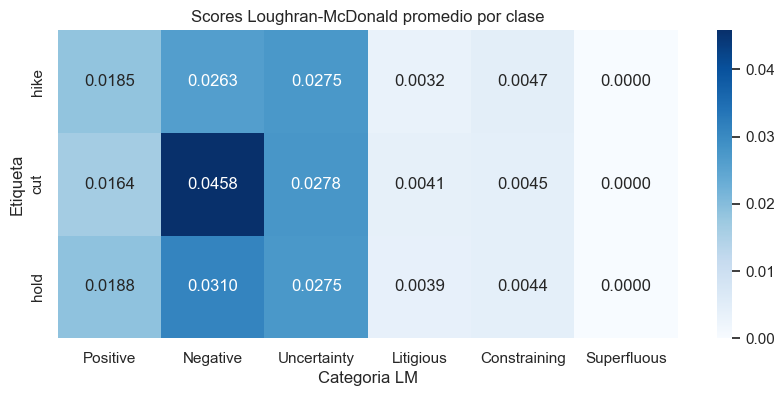

In [9]:
if not LM_AVAILABLE:
    print('Lexicon LM no disponible — omitiendo analisis. Ver instrucciones en celda anterior.')
else:
    LM_CATEGORIES = ['Positive', 'Negative', 'Uncertainty', 'Litigious', 'Constraining', 'Superfluous']

    word_col = 'Word' if 'Word' in lm_df.columns else lm_df.columns[0]
    lm_sets = {}
    for cat in LM_CATEGORIES:
        col_match = [c for c in lm_df.columns if cat.lower() in c.lower()]
        if col_match:
            lm_sets[cat] = set(lm_df.loc[lm_df[col_match[0]] != 0, word_col].str.lower())
        else:
            lm_sets[cat] = set()
            print(f'Advertencia: categoria {cat} no encontrada.')

    print('Tamano de cada conjunto LM:')
    for cat, words in lm_sets.items():
        print(f'  {cat:15s}: {len(words)} palabras')

    def lm_score(text, word_set):
        tokens = str(text).split()
        if not tokens:
            return 0.0
        return sum(1 for t in tokens if t in word_set) / len(tokens)

    for cat in LM_CATEGORIES:
        col = f'lm_{cat.lower()}'
        df[col] = df['text'].apply(lambda t, s=lm_sets[cat]: lm_score(t, s))

    lm_cols = [f'lm_{c.lower()}' for c in LM_CATEGORIES]

    scores_label = df.groupby('label')[lm_cols].mean()
    scores_label.columns = LM_CATEGORIES
    print('\nScore LM promedio por clase:')
    display(scores_label.round(4))

    fig, ax = plt.subplots(figsize=(10, 4))
    sns.heatmap(scores_label.loc[LABEL_ORDER], annot=True, fmt='.4f', cmap='Blues', ax=ax)
    ax.set_title('Scores Loughran-McDonald promedio por clase')
    ax.set_xlabel('Categoria LM')
    ax.set_ylabel('Etiqueta')
    save_fig('03_lm_scores_per_class.png')
    plt.show()

Score LM promedio por epoca:


,Positive,Negative,Uncertainty,Litigious,Constraining,Superfluous
epoch,,,,,,
post-2005,0.0177,0.0310,0.0270,0.0037,0.0046,0.0
pre-2005,0.0214,0.0349,0.0295,0.0039,0.0039,0.0


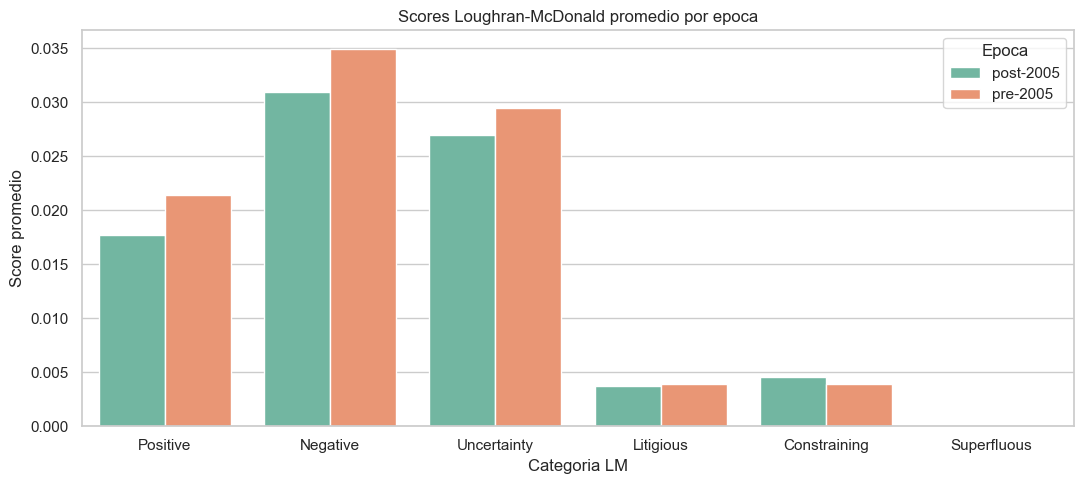

In [10]:
if not LM_AVAILABLE:
    print('Lexicon LM no disponible — omitiendo analisis por epoca.')
else:
    scores_epoch = df.groupby('epoch')[lm_cols].mean()
    scores_epoch.columns = LM_CATEGORIES
    print('Score LM promedio por epoca:')
    display(scores_epoch.round(4))

    scores_melt = (
        scores_epoch.T
        .reset_index()
        .rename(columns={'index': 'Categoria'})
        .melt(id_vars='Categoria', var_name='Epoca', value_name='Score')
    )

    fig, ax = plt.subplots(figsize=(11, 5))
    sns.barplot(data=scores_melt, x='Categoria', y='Score', hue='Epoca', ax=ax)
    ax.set_title('Scores Loughran-McDonald promedio por epoca')
    ax.set_xlabel('Categoria LM')
    ax.set_ylabel('Score promedio')
    plt.tight_layout()
    save_fig('03_lm_scores_per_epoch.png')
    plt.show()